In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/cleaned_cars.csv")

df.shape

(37812, 56)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37812 entries, 0 to 37811
Data columns (total 56 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   loc                      37812 non-null  str    
 1   bt                       37812 non-null  str    
 2   km                       37812 non-null  int64  
 3   pu                       37812 non-null  int64  
 4   Color                    37812 non-null  str    
 5   Engine Type              37812 non-null  str    
 6   Displacement             37812 non-null  float64
 7   Max Power                37812 non-null  float64
 8   Max Torque               37812 non-null  float64
 9   No of Cylinder           37812 non-null  float64
 10  Values per Cylinder      37812 non-null  float64
 11  Value Configuration      37812 non-null  str    
 12  Turbo Charger            37812 non-null  str    
 13  Super Charger            37812 non-null  str    
 14  Length                   37812 no

we have 31 categorical columns now we start EDA

TARGET VARIABLE ANALYSIS (MOST IMPORTANT)

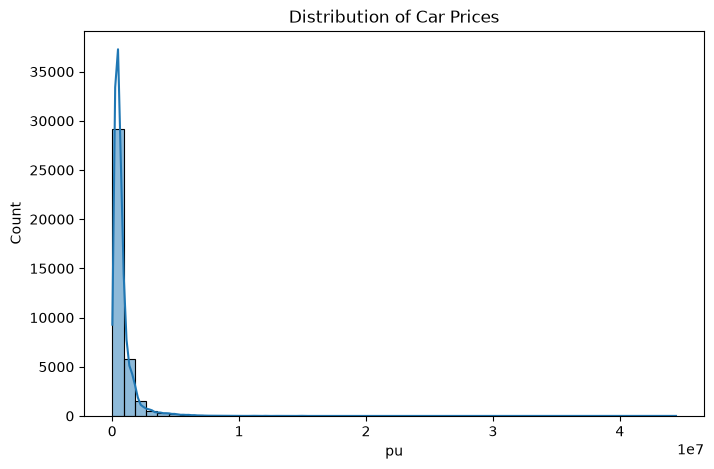

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df["pu"], bins=50, kde=True)
plt.title("Distribution of Car Prices")
plt.show()

### Insight
Car prices are highly right-skewed, with most cars concentrated in the lower price range and a few luxury cars forming a long tail. This indicates the presence of outliers and non-normal distribution.

Problems:
Model will be biased toward cheap cars
Poor prediction for expensive cars
High error variance
Linear models especially perform badly
SOLUTION - Log Transformation

In [5]:
import numpy as np

df["log_price"] = np.log1p(df["pu"])

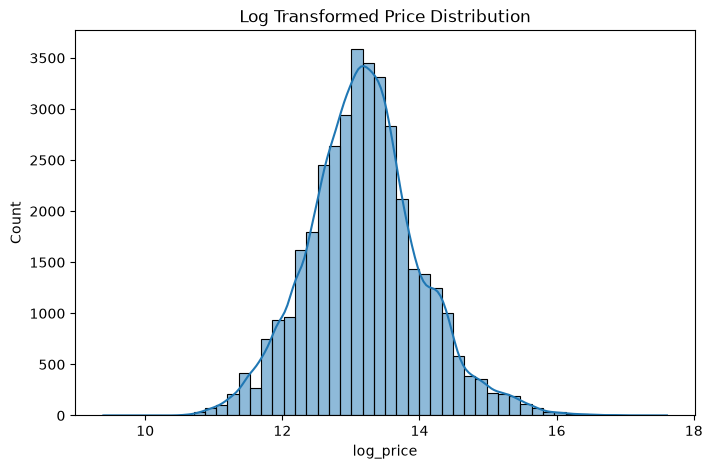

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df["log_price"], bins=50, kde=True)
plt.title("Log Transformed Price Distribution")
plt.show()

### Insight
After log transformation, the price distribution becomes more normalized and symmetric. This helps stabilize variance and improves model performance for regression algorithms.

which brands are most expensive 

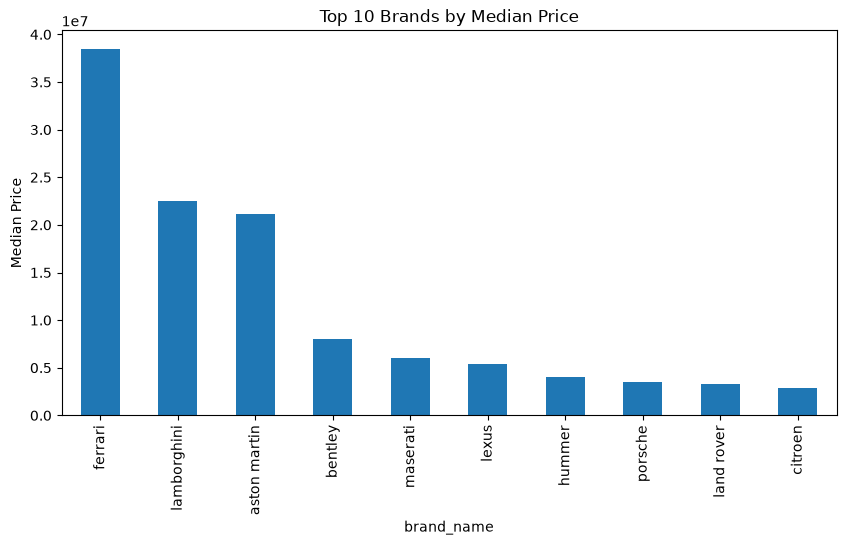

In [7]:
top_brands = df.groupby("brand_name")["pu"].median().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_brands.plot(kind="bar")
plt.title("Top 10 Brands by Median Price")
plt.ylabel("Median Price")
plt.show()

### Insight
Luxury brands such as Ferrari and Lamborghini have significantly higher median prices compared to mass-market brands, showing that brand is a strong determinant of car pricing.

Fuel Type vs Price (Boxplot)

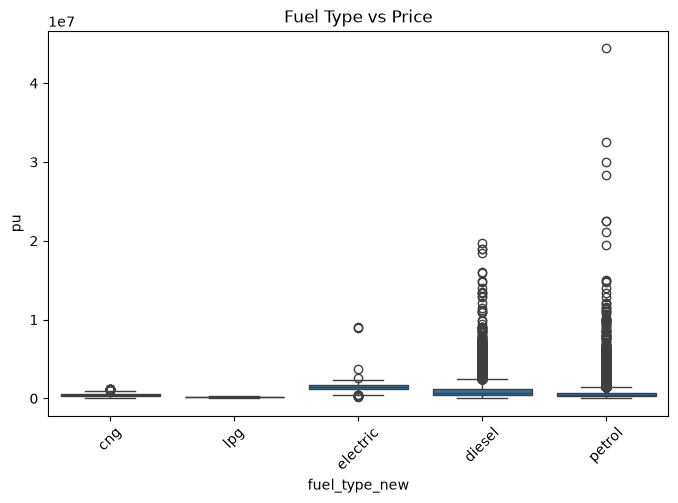

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(x="fuel_type_new", y="pu", data=df)
plt.xticks(rotation=45)
plt.title("Fuel Type vs Price")
plt.show()

### Insight
Fuel type shows clear variation in price distribution. Diesel and petrol cars dominate higher price ranges, while CNG and LPG vehicles are generally lower priced. Electric vehicles show a niche but higher pricing trend.

Transmission vs Price

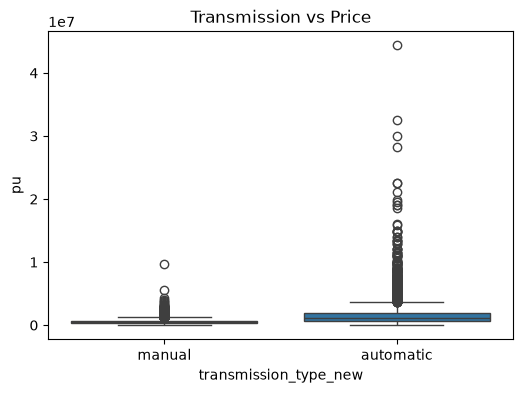

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(x="transmission_type_new", y="pu", data=df)
plt.title("Transmission vs Price")
plt.show()

### Insight
Automatic cars have significantly higher median prices compared to manual cars, indicating that transmission type is a strong predictor of car value.

CORRELATION HEATMAP 

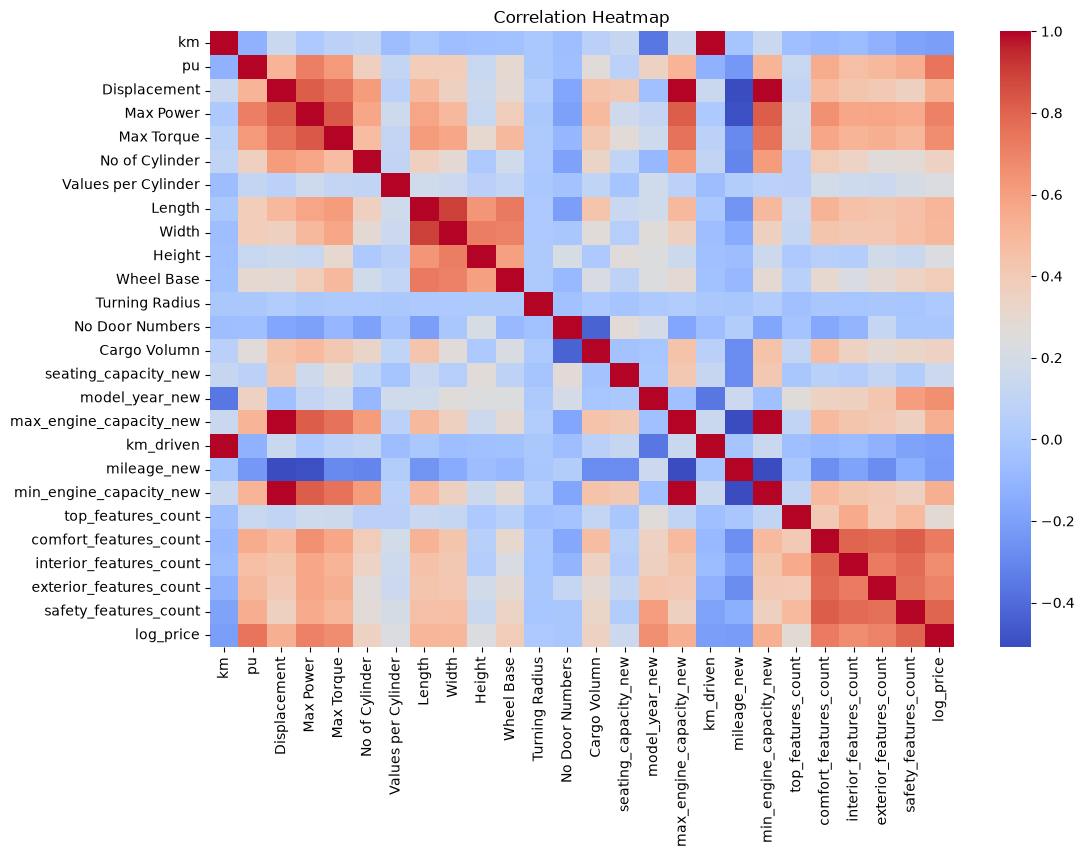

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

num_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12,8))
sns.heatmap(num_df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Insight
Price is strongly correlated with engine-related features such as power, torque, and displacement, as well as vehicle size and feature counts. Several features are highly inter-correlated, indicating multicollinearity.

In [11]:
df_fe = df.copy()

In [12]:
y = df_fe["pu"]

In [13]:
X = df_fe.drop("pu", axis=1)

FINDING CATEGORICAL COLUMNS (TEXT)

In [14]:
cat_cols = X.select_dtypes(include=["object", "string"]).columns
cat_cols

Index(['loc', 'bt', 'Color', 'Engine Type', 'Value Configuration',
       'Turbo Charger', 'Super Charger', 'Gear Box', 'Drive Type',
       'Steering Type', 'Front Brake Type', 'Rear Brake Type', 'Tyre Type',
       'model_type_new', 'car_type_new', 'oem_name', 'state',
       'transmission_type_new', 'model_new', 'vehicle_type_new', 'brand_name',
       'engine_cc', 'fuel_type_new', 'car_segment', 'city_name_new',
       'engine_capacity_new', 'body_type_new', 'owner_type_new',
       'variant_name', 'exterior_color', 'Fuel Suppy System'],
      dtype='str')

CLASSIFYING COLUMNS 

In [15]:
low_card_cols = [col for col in cat_cols if X[col].nunique() < 10]
high_card_cols = [col for col in cat_cols if X[col].nunique() >= 10]

low_card_cols, high_card_cols

(['Turbo Charger',
  'Super Charger',
  'model_type_new',
  'car_type_new',
  'transmission_type_new',
  'vehicle_type_new',
  'engine_cc',
  'fuel_type_new',
  'engine_capacity_new',
  'owner_type_new'],
 ['loc',
  'bt',
  'Color',
  'Engine Type',
  'Value Configuration',
  'Gear Box',
  'Drive Type',
  'Steering Type',
  'Front Brake Type',
  'Rear Brake Type',
  'Tyre Type',
  'oem_name',
  'state',
  'model_new',
  'brand_name',
  'car_segment',
  'city_name_new',
  'body_type_new',
  'variant_name',
  'exterior_color',
  'Fuel Suppy System'])

ENCODING LOW CARDINALITY COLUMNS 

In [16]:
X_encoded = pd.get_dummies(X, columns=low_card_cols, drop_first=True)

ENCODING HIGH CARDINALITY COLUMNS - FREQUENCY ENCODING 

In [17]:
X_fe = X_encoded.copy()

for col in high_card_cols:
    freq_map = X_fe[col].value_counts() / len(X_fe)
    X_fe[col] = X_fe[col].map(freq_map)

In [18]:
X_fe.shape

(37812, 70)

In [19]:
X_fe.shape
y.shape

(37812,)

In [20]:
X_fe.shape, y.shape

((37812, 70), (37812,))

TRAIN–TEST SPLIT

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_fe,
    y,
    test_size=0.2,
    random_state=42
)

VERIFY SPLIT

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((30249, 70), (7563, 70), (30249,), (7563,))

copying the contents of dataset so while training so we dont alter the original

In [25]:
# Save the feature-engineered dataset

final_data = X_fe.copy()
final_data["Price"] = y

final_data.to_csv(
    "../data/processed/final_feature_engineered_data.csv",
    index=False
)

print("Dataset saved successfully!")
print(final_data.shape)

Dataset saved successfully!
(37812, 71)
